In [8]:
import warnings
warnings.filterwarnings('ignore')

2007 年青少年目前飲酒的比例是否不同於基準值 $p_{0} = 0.35$？

2007 年青少年的平均體重是否不同於基準值 $\mu_{0} = 68.0$ 公斤？

In [9]:
import pandas as pd

# 1. 讀取原始資料 (使用相對路徑，這樣組員下載也能跑)
# 假設你的 Notebook 存放在 notebooks/ 資料夾下
df = pd.read_csv('../data/raw/YRBS_2007.csv')

# 2. 資料檢查：看看這兩個變數有多少缺失值
print(df[['CurrentAlcoholUse', 'HowMuchDoYouWeighWithoutShoesInKG']].isnull().sum())

# 3. 重編碼 CurrentAlcoholUse (定義成功與失敗)
# 依照手冊：2-7 為成功(1), 1 為失敗(0)
df['alcohol_success'] = df['CurrentAlcoholUse'].apply(lambda x: 1 if 2 <= x <= 7 else (0 if x == 1 else None))

CurrentAlcoholUse                    1372
HowMuchDoYouWeighWithoutShoesInKG     979
dtype: int64


In [10]:
# 建立一個清理後的 DataFrame，排除這兩個欄位的缺失值
df_cleaned = df.dropna(subset=['CurrentAlcoholUse', 'HowMuchDoYouWeighWithoutShoesInKG']).copy()

# 確認清理後的樣本數 (這是作業要求的 Final sample size)
print(f"原始資料筆數: {len(df)}")
print(f"清理後有效樣本數: {len(df_cleaned)}")

原始資料筆數: 14041
清理後有效樣本數: 11843


In [11]:
# 執行重編碼：把 2-7 設為 1 (Success)，把 1 設為 0 (Failure)
df_cleaned['alcohol_binary'] = df_cleaned['CurrentAlcoholUse'].apply(lambda x: 1 if 2 <= x <= 7 else 0)

# 檢查重編碼後的結果
print(df_cleaned['alcohol_binary'].value_counts())

alcohol_binary
0    6449
1    5394
Name: count, dtype: int64


In [12]:
# 將清理後的資料存成新檔案
df_cleaned.to_csv('../data/processed/yrbs_cleaned.csv', index=False)

次數分配：
alcohol_binary
0    6449
1    5394
Name: count, dtype: int64

百分比分配：
alcohol_binary
0    0.544541
1    0.455459
Name: proportion, dtype: float64


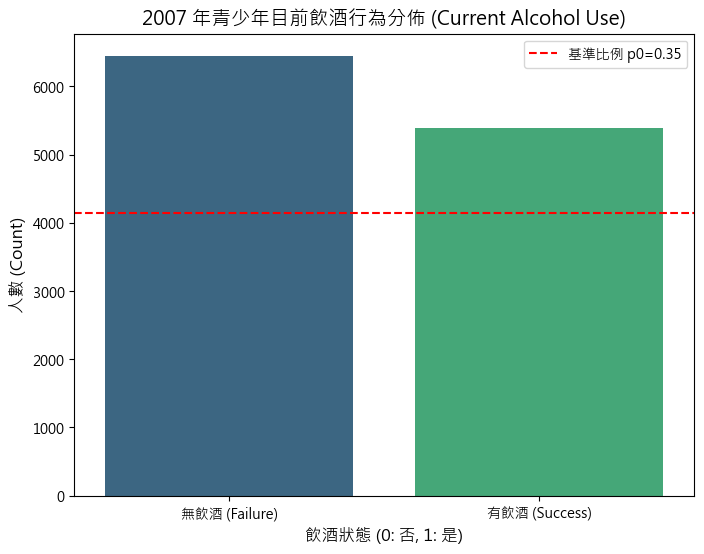

In [14]:
import matplotlib.pyplot as plt

# 設定字體為 Windows 內建的「微軟正黑體」
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] 

# 解決座標軸負號 (-) 顯示為方塊的問題
plt.rcParams['axes.unicode_minus'] = False

import seaborn as sns

# 1. 計算頻率與比例
alcohol_counts = df_cleaned['alcohol_binary'].value_counts().sort_index()
alcohol_perc = df_cleaned['alcohol_binary'].value_counts(normalize=True).sort_index()

print("次數分配：")
print(alcohol_counts)
print("\n百分比分配：")
print(alcohol_perc)

# 2. 繪製長條圖
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='alcohol_binary', data=df_cleaned, palette='viridis')

# 3. 在圖上加上標籤與標題
plt.title('2007 年青少年目前飲酒行為分佈 (Current Alcohol Use)', fontsize=14)
plt.xlabel('飲酒狀態 (0: 否, 1: 是)', fontsize=12)
plt.ylabel('人數 (Count)', fontsize=12)
plt.xticks([0, 1], ['無飲酒 (Failure)', '有飲酒 (Success)'])

# 4. 畫出一條紅色的基準線 (p0 = 0.35) 供視覺參考
# 注意：這裡畫的是比例線，如果 y 軸是人數，需轉換
total_n = len(df_cleaned)
plt.axhline(y=total_n * 0.35, color='red', linestyle='--', label='基準比例 p0=0.35')
plt.legend()

# 5. 儲存圖檔 (符合作業規範存入 outputs/figures/)
plt.savefig('../outputs/figures/alcohol_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

樣本平均體重: 68.43 kg
樣本標準差: 16.90 kg


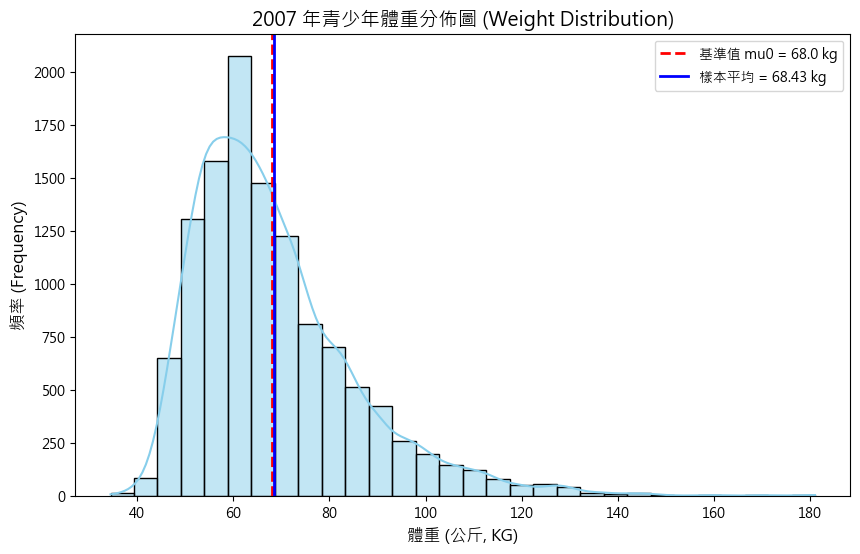

In [15]:
import matplotlib.pyplot as plt

# 設定字體為 Windows 內建的「微軟正黑體」
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] 

# 解決座標軸負號 (-) 顯示為方塊的問題
plt.rcParams['axes.unicode_minus'] = False
import seaborn as sns

# 1. 計算基本的統計量（這在寫報告時會用到）
weight_mean = df_cleaned['HowMuchDoYouWeighWithoutShoesInKG'].mean()
weight_std = df_cleaned['HowMuchDoYouWeighWithoutShoesInKG'].std()
print(f"樣本平均體重: {weight_mean:.2f} kg")
print(f"樣本標準差: {weight_std:.2f} kg")

# 2. 繪製直方圖
plt.figure(figsize=(10, 6))
# kde=True 會畫出一條平滑的密度曲線，幫助看分佈形狀
sns.histplot(df_cleaned['HowMuchDoYouWeighWithoutShoesInKG'], kde=True, color='skyblue', bins=30)

# 3. 畫出基準線 (mu0 = 68.0)
plt.axvline(x=68.0, color='red', linestyle='--', linewidth=2, label='基準值 mu0 = 68.0 kg')
# 畫出樣本平均線（藍色實線）
plt.axvline(x=weight_mean, color='blue', linestyle='-', linewidth=2, label=f'樣本平均 = {weight_mean:.2f} kg')

# 4. 設定圖表標籤與標題
plt.title('2007 年青少年體重分佈圖 (Weight Distribution)', fontsize=14)
plt.xlabel('體重 (公斤, KG)', fontsize=12)
plt.ylabel('頻率 (Frequency)', fontsize=12)
plt.legend()

# 5. 儲存圖檔
plt.savefig('../outputs/figures/weight_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
from statsmodels.stats.proportion import proportions_ztest

# 1. 準備數據：成功次數 (count) 與總樣本數 (nobs)
count = df_cleaned['alcohol_binary'].sum()
nobs = len(df_cleaned)

# 2. 執行 Z 檢定
z_stat, p_value = proportions_ztest(count, nobs, value=0.35)

print(f"比例檢定結果：")
print(f"Z 檢定量: {z_stat:.4f}")
print(f"P 值: {p_value:.4f}")

# 3. 判斷結果
if p_value < 0.05:
    print("結果：拒絕虛無假設 (Reject H0)，飲酒比例與 0.35 有顯著差異。")
else:
    print("結果：無法拒絕虛無假設 (Fail to reject H0)，無足夠證據顯示有顯著差異。")

比例檢定結果：
Z 檢定量: 23.0449
P 值: 0.0000
結果：拒絕虛無假設 (Reject H0)，飲酒比例與 0.35 有顯著差異。


In [17]:
from scipy import stats

# 1. 執行單一樣本 T 檢定
t_stat, p_val_t = stats.ttest_1samp(df_cleaned['HowMuchDoYouWeighWithoutShoesInKG'], popmean=68.0)

print(f"平均數檢定結果：")
print(f"T 檢定量: {t_stat:.4f}")
print(f"P 值: {p_val_t:.4f}")

# 2. 判斷結果
if p_val_t < 0.05:
    print("結果：拒絕虛無假設 (Reject H0)，平均體重與 68.0 kg 有顯著差異。")
else:
    print("結果：無法拒絕虛無假設 (Fail to reject H0)，無足夠證據顯示有顯著差異。")

平均數檢定結果：
T 檢定量: 2.7429
P 值: 0.0061
結果：拒絕虛無假設 (Reject H0)，平均體重與 68.0 kg 有顯著差異。


In [18]:
# 建立摘要表
summary_results = pd.DataFrame({
    'Test_Type': ['Proportion (Alcohol)', 'Mean (Weight)'],
    'Test_Statistic': [z_stat, t_stat],
    'P_Value': [p_value, p_val_t],
    'Conclusion': ['Significant' if p_value < 0.05 else 'Not Significant',
                   'Significant' if p_val_t < 0.05 else 'Not Significant']
})

# 儲存到指定資料夾
summary_results.to_csv('../outputs/tables/statistical_results.csv', index=False)
print("統計結果已存入 outputs/tables/ )

統計結果已存入 outputs/tables/ !
